In [12]:
import torch
import typing as t
from tqdm import tqdm
from torch.utils.data import DataLoader

from v1t import data
from v1t.utils import utils
from v1t.models import Model
from v1t.metrics import Metrics
from v1t.utils.scheduler import Scheduler


In [13]:
class Args:
    def __init__(self, output_dir):
        self.dataset = "/user/azhar.akhmetova/corrViT/V1T/data/sensorium"
        self.output_dir = output_dir
        self.device = torch.device("cpu")
        self.batch_size = 1

#./runs/25_13_12_3_2/runs_3a_adj_state/add_noise/output_2_std_200/
args = Args("/user/azhar.akhmetova/corrViT/V1T/runs/s3_c2_25_12.5_12_12_2_4_norm/runs_1_state/output_2")
utils.load_args(args)

In [4]:
train_ds, val_ds, test_ds = data.get_training_ds(
    args,
    data_dir=args.dataset,
    mouse_ids=args.mouse_ids,
    batch_size=args.batch_size,
    device=args.device,
)


In [5]:
model = Model(args, ds=train_ds)
model.to(args.device)

scheduler = Scheduler(args, model=model, save_optimizer=False)
_ = scheduler.restore(force=True)

Enable gradient checkpointing in ViT

Loaded checkpoint from epoch 257 (correlation: 0.4562).



/srv/user/azhar.akhmetova/corrViT/V1T/src/v1t/utils/scheduler.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_location=self.device)


In [6]:
args1 = Args("/user/azhar.akhmetova/corrViT/V1T/runs/s3_c2_25_12.5_12_12_2_4_norm/runs_1_state/output_3")
utils.load_args(args1)
train_ds, val_ds, test_ds = data.get_training_ds(
    args1,
    data_dir=args1.dataset,
    mouse_ids=args1.mouse_ids,
    batch_size=args1.batch_size,
    device=args1.device,
)

model1 = Model(args1, ds=train_ds)
model1.to(args1.device)

scheduler = Scheduler(args1, model=model1, save_optimizer=False)
_ = scheduler.restore(force=True)

Enable gradient checkpointing in ViT

Loaded checkpoint from epoch 223 (correlation: 0.4602).



/srv/user/azhar.akhmetova/corrViT/V1T/src/v1t/utils/scheduler.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_location=self.device)


In [14]:
args2 = Args("/user/azhar.akhmetova/corrViT/V1T/runs/s3_c2_25_12.5_12_12_2_4_norm/runs_1_state/output_1")
utils.load_args(args2)
train_ds, val_ds, test_ds = data.get_training_ds(
    args2,
    data_dir=args2.dataset,
    mouse_ids=args2.mouse_ids,
    batch_size=args2.batch_size,
    device=args2.device,
)

model2 = Model(args2, ds=train_ds)
model2.to(args2.device)

scheduler = Scheduler(args2, model=model2, save_optimizer=False)
_ = scheduler.restore(force=True)

Enable gradient checkpointing in ViT

Loaded checkpoint from epoch 360 (correlation: 0.4495).



/srv/user/azhar.akhmetova/corrViT/V1T/src/v1t/utils/scheduler.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_location=self.device)


In [15]:
@torch.no_grad()
def inference(
    ds: DataLoader,
    model: torch.nn.Module,
    batch_size: int,
    device: torch.device = "cpu",
) -> t.Dict[str, torch.Tensor]:
    """Inference data in DataLoader ds
    Returns:
        results: t.Dict[int, t.Dict[str, torch.Tensor]]
            - mouse_id
                - predictions: torch.Tensor, predictions given images
                - targets: torch.Tensor, the ground-truth responses
                - trial_ids: torch.Tensor, trial ID of the responses
                - image_ids: torch.Tensor, image ID of the responses
    """
    results = {
        "predictions": [],
        "targets": [],
        "trial_ids": [],
        "image_ids": [],
    }
    mouse_id = ds.dataset.mouse_id
    model.to(device)
    model.train(False)
    for batch in tqdm(ds, desc=f"Mouse {mouse_id}"):
        for micro_batch in data.micro_batching(batch, batch_size=batch_size):
            predictions, _, _ = model(
                inputs=micro_batch["image"].to(device),
                mouse_id=mouse_id,
                behaviors=micro_batch["behavior"].to(device),
                pupil_centers=micro_batch["pupil_center"].to(device),
            )
            results["predictions"].append(predictions.cpu())
            results["targets"].append(micro_batch["response"])
            results["image_ids"].append(micro_batch["image_id"])
            results["trial_ids"].append(micro_batch["trial_id"])
    results = {
        k: torch.cat(v, dim=0) if isinstance(v[0], torch.Tensor) else v
        for k, v in results.items()
    }
    return results


In [20]:
for mouse_id in ["1_s3_c2_125_norm"]:
    outputs = inference(
        ds=test_ds[mouse_id],
        model=model,
        batch_size=args.batch_size,
        device=args.device,
    )
    metrics = Metrics(ds=test_ds[mouse_id], results=outputs)

    single_trial_correlation = metrics.single_trial_correlation(per_neuron=False)
    correlation_to_average = metrics.correlation_to_average(per_neuron=False)
    print(
        f"single trial correlation: {single_trial_correlation:.03f}\n"
        f"correlation to average: {correlation_to_average:.03f}\n"
    )


Mouse 1_s3_c2_125_norm: 100%|██████████| 990/990 [01:29<00:00, 11.06it/s]


(990,)
(990,)
single trial correlation: 0.458
correlation to average: 0.478



In [22]:
single_trial_correlation

0.4575239453145748

In [18]:
for mouse_id in ["1_s3_c2_125_norm"]:
    outputs = inference(
        ds=test_ds[mouse_id],
        model=model1,
        batch_size=args1.batch_size,
        device=args1.device,
    )
    metrics = Metrics(ds=test_ds[mouse_id], results=outputs)

    single_trial_correlation1 = metrics.single_trial_correlation(per_neuron=False)
    correlation_to_average = metrics.correlation_to_average(per_neuron=False)
    print(
        f"single trial correlation: {single_trial_correlation:.03f}\n"
        f"correlation to average: {correlation_to_average:.03f}\n"
    )


Mouse 1_s3_c2_125_norm: 100%|██████████| 990/990 [01:27<00:00, 11.28it/s]


(990,)
(990,)
single trial correlation: 0.458
correlation to average: 0.477



In [19]:
single_trial_correlation1

0.45768216752152496

In [ ]:
for mouse_id in ["1_s3_c2_125_norm"]:
    outputs = inference(
        ds=test_ds[mouse_id],
        model=model2,
        batch_size=args2.batch_size,
        device=args2.device,
    )
    metrics = Metrics(ds=test_ds[mouse_id], results=outputs)

    single_trial_correlation2 = metrics.single_trial_correlation(per_neuron=False)
    correlation_to_average = metrics.correlation_to_average(per_neuron=False)
    print(
        f"single trial correlation: {single_trial_correlation2:.03f}\n"
        f"correlation to average: {correlation_to_average:.03f}\n"
    )


Mouse 1_s3_c2_125_norm: 100%|██████████| 990/990 [01:27<00:00, 11.37it/s]


(990,)
(990,)
single trial correlation: 0.458
correlation to average: 0.468



In [17]:
single_trial_correlation2

0.44870038214212665

In [23]:
import numpy as np
np.mean([0.4575239453145748, 0.45768216752152496, 0.44870038214212665])

0.45463549832607547

In [25]:
np.std([0.4575239453145748, 0.45768216752152496, 0.44870038214212665])

0.004197257966372922

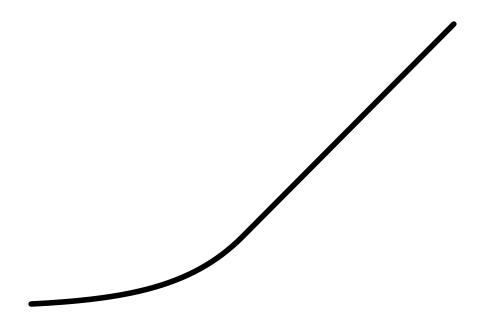

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Define the ELU function
def elu_plus_one(x, alpha=1.0):
    return np.where(x > 0, x + 1, alpha * (np.exp(x) - 1) + 1)

# Generate x values
x = np.linspace(-3, 3, 500)

# Compute y values
y = elu_plus_one(x)

# Create the plot
plt.figure(figsize=(6, 4))
plt.plot(x, y, label=r"ELU + 1", color='black', linewidth=4)

# Remove grid and frame
plt.axis('off')

# Show the plot
plt.show()
